In [49]:
import os

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)

import random
import numpy as np
import pandas as pd
import tensorflow as tf

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.config.experimental.enable_op_determinism()

In [50]:
df = pd.read_csv('../data/df_with_2regimes.csv')

# take log of realized variance
df['log_realized_variance'] = np.log(df['realized_variance'])
# lag 1,2 andd 3 of log realized variance
df['rv_lag1'] = df['log_realized_variance'].shift(1)
df['rv_lag2'] = df['log_realized_variance'].shift(2)
df['rv_lag3'] = df['log_realized_variance'].shift(3)

# rolling mean of log realized variance over the past 30 days
df['rv_rolling_mean_30'] = df['log_realized_variance'].rolling(window=30).mean() 

# drop rows with NaN values (due to lag and rolling mean)
df = df.dropna().reset_index(drop=True)
#df.head(30)
#df.info()
# start from 2017-07-13
df = df[df['date'] >= '2017-07-13'].reset_index(drop=True)
#print(df.isna().sum())

In [4]:
svr_features = ["log_realized_variance","rv_lag1", "rv_lag2", "rv_lag3", "rv_rolling_mean_30"]

## Neutral Regime Predictor

In [51]:
def rolling_regime_forecast_neutral(
    df_full,
    start_idx,
    end_idx,
    date_col="date"
):

    results = []

    for t in range(start_idx - 1, end_idx - 1):

        results.append({
            "date": df_full.iloc[t][date_col],
            "pred_regime": 0,         
            "pred_prob_0": 0.5,
            "pred_prob_1": 0.5
        })

    return pd.DataFrame(results)

In [52]:
def one_step_svr_forecast(fitted_svr, x_next):
    
    if fitted_svr is None:
        return np.nan

    try:
        x_next = np.asarray(x_next).reshape(1, -1)
        pred = fitted_svr.predict(x_next)[0]
        return float(pred)
    except Exception:
        return np.nan

    
def fit_svr_safe(X_train, y_train, C=1.0, epsilon=1e-4, min_obs=100):
    if len(X_train) < min_obs:
        return None

    try:
        model = LinearSVR(C=C, epsilon=epsilon, dual=True, max_iter=20000, random_state = SEED)
        model.fit(X_train, y_train)
        return model
    except Exception as e:
        print("LinearSVR fit failed:", e)
        return None

In [53]:
def rolling_lstm_svr_linear_eval(
    df_full,
    regime_forecast_df,
    start_idx,
    end_idx,
    x_feature_cols,
    realized_var_col="log_realized_variance",
    date_col="date",
    rolling_window=365,
    C=1.0,
    epsilon=1e-4,
    min_obs=200,
    use_prob_1_only=True
):
    results = []

    df = df_full.copy()
    regime_df = regime_forecast_df.copy()

    merge_cols = [date_col, "pred_regime", "pred_prob_0", "pred_prob_1"]
    df = df.merge(regime_df[merge_cols], on=date_col, how="left")

    # target is next day's realized variance
    df["rv_lead1"] = df[realized_var_col].shift(-1)

    # row t stores regime forecast for t+1 made using info up to t
    df["prob1_for_next_day"] = df["pred_prob_1"]
    df["prob0_for_next_day"] = df["pred_prob_0"]
    df["regime_for_next_day"] = df["pred_regime"]

    prob_cols = ["prob1_for_next_day"] if use_prob_1_only else ["prob0_for_next_day", "prob1_for_next_day"]
    feature_cols = x_feature_cols + prob_cols

    for t in range(start_idx - 1, end_idx - 1):
        current_row = df.iloc[t]
        next_row = df.iloc[t + 1]

        current_date = current_row[date_col]
        next_date = next_row[date_col]

        # training ends at t-1, so row t is excluded
        window_df = df.iloc[max(0, t - rolling_window + 1): t].copy()

        needed_cols = feature_cols + ["rv_lead1"]
        train_df = window_df[needed_cols].dropna()

        if len(train_df) < min_obs:
            results.append({
                "date": next_date,
                "forecast_origin_date": current_date,
                "actual_var": next_row[realized_var_col],
                "pred_regime": current_row.get("regime_for_next_day", np.nan),
                "pred_prob_0": current_row.get("prob0_for_next_day", np.nan),
                "pred_prob_1": current_row.get("prob1_for_next_day", np.nan),
                "var_svr": np.nan
            })
            continue

        # split continuous features and probability features
        X_train_cont = train_df[x_feature_cols].values
        X_train_prob = train_df[prob_cols].values
        y_train = train_df["rv_lead1"].values

        # scale only continuous features
        scaler = StandardScaler()
        X_train_cont_scaled = scaler.fit_transform(X_train_cont)

        # combine scaled continuous features with raw probabilities
        X_train_final = np.hstack([X_train_cont_scaled, X_train_prob])

        model = fit_svr_safe(
            X_train=X_train_final,
            y_train=y_train,
            C=C,
            epsilon=epsilon,
            min_obs=min_obs
        )

        # prepare current row features for forecasting t+1
        x_t_cont = current_row[x_feature_cols]
        x_t_prob = current_row[prob_cols]

        if x_t_cont.isna().any() or x_t_prob.isna().any():
            pred = np.nan
        else:
            x_t_cont_scaled = scaler.transform(x_t_cont.values.reshape(1, -1))
            x_t_prob_arr = x_t_prob.values.reshape(1, -1)
            x_t_final = np.hstack([x_t_cont_scaled, x_t_prob_arr])

            pred = one_step_svr_forecast(model, x_t_final)

        results.append({
            "date": next_date,
            "forecast_origin_date": current_date,
            "actual_log_var": next_row[realized_var_col],
            "pred_regime": current_row.get("regime_for_next_day", np.nan),
            "pred_prob_0": current_row.get("prob0_for_next_day", np.nan),
            "pred_prob_1": current_row.get("prob1_for_next_day", np.nan),
            "log_var_svr": pred
        })

    return pd.DataFrame(results)

In [54]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    return np.sqrt(np.mean((y_true[mask] - y_pred[mask]) ** 2))


def qlike(test_actuals, test_preds): 
    test_actuals = np.asarray(test_actuals, dtype=float)
    test_preds = np.asarray(test_preds, dtype=float)

    test_qlike = np.mean(test_actuals / (test_preds + 1e-10) - np.log(test_actuals / (test_preds + 1e-10)) - 1)

    return test_qlike 


In [55]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import backend as K
import tensorflow as tf
import gc
from itertools import product 
from sklearn.svm import SVR
from sklearn.svm import LinearSVR
from sklearn.preprocessing import StandardScaler


In [56]:
n = len(df)

train_size = int(n * 0.60)  # 60/25/15 split
eval_size  = int(n * 0.25)

train_start_idx = 0
train_end_idx   = train_size

eval_start_idx = train_end_idx
eval_end_idx   = eval_start_idx + eval_size

test_start_idx = eval_end_idx
test_end_idx   = n

# split eval into A and B
evalA_size = eval_size // 2

evalA_start_idx = eval_start_idx
evalA_end_idx   = evalA_start_idx + evalA_size

evalB_start_idx = evalA_end_idx
evalB_end_idx   = eval_end_idx

train_df = df.iloc[train_start_idx:train_end_idx].copy()
evalA_df = df.iloc[evalA_start_idx:evalA_end_idx].copy()
evalB_df = df.iloc[evalB_start_idx:evalB_end_idx].copy()
test_df  = df.iloc[test_start_idx:test_end_idx].copy()

print(f"Train set:  {len(train_df)} rows")
print(f"Eval A set: {len(evalA_df)} rows")
print(f"Eval B set: {len(evalB_df)} rows")
print(f"Test set:   {len(test_df)} rows")

Train set:  1875 rows
Eval A set: 390 rows
Eval B set: 391 rows
Test set:   469 rows


In [57]:
train_start_idx = 0
train_end_idx = train_size

eval_start_idx = train_size
eval_end_idx = train_size + eval_size

test_start_idx = eval_end_idx
test_end_idx = len(df)

In [58]:
# tune svr-l using evalB
svr_grid = {
    "kernel": ["linear"],
    "C": [0.1, 1.0, 10.0],
    "epsilon": [1e-4, 1e-3, 1e-2]
}

svr_param_grid = []
for kernel, C, epsilon in product(
    svr_grid["kernel"],
    svr_grid["C"],
    svr_grid["epsilon"]
):
    svr_param_grid.append({
        "kernel": kernel,
        "C": C,
        "epsilon": epsilon
    })
print(f"Total SVR parameter combinations: {len(svr_param_grid)}")

Total SVR parameter combinations: 9


In [59]:
stage2_window = 365
regime_start_idx = max(0, evalB_start_idx - stage2_window)

evalB_regime_neutral = rolling_regime_forecast_neutral(
    df_full=df,
    start_idx=regime_start_idx,
    end_idx=evalB_end_idx,
    date_col="date"
)

In [60]:
svr_results = []

for i, params in enumerate(svr_param_grid, 1):
    kernel = params["kernel"]
    C = params["C"]
    epsilon = params["epsilon"]

    print(f"\n[{i}/{len(svr_param_grid)}] Testing SVR: {params}")

    try:
        evalB_svr = rolling_lstm_svr_linear_eval(
            df_full=df,
            regime_forecast_df=evalB_regime_neutral,
            start_idx=evalB_start_idx,
            end_idx=evalB_end_idx,
            x_feature_cols=svr_features,
            realized_var_col="log_realized_variance",
            date_col="date",
            rolling_window=365,
            C=C,
            epsilon=epsilon,
            min_obs=200,
            use_prob_1_only=True
        )

        evalB_rmse = rmse(evalB_svr["actual_log_var"], evalB_svr["log_var_svr"])
        # convert to variance scale for qlike
        evalB_qlike = qlike(np.exp(evalB_svr["actual_log_var"]), np.exp(evalB_svr["log_var_svr"]))
        n_evalB_forecasts = evalB_svr["log_var_svr"].notna().sum()

        svr_results.append({
            **params,
            "evalB_rmse": evalB_rmse,
            "evalB_qlike": evalB_qlike,
            "n_evalB_forecasts": n_evalB_forecasts
        })

    except Exception as e:
        svr_results.append({
            **params,
            "evalB_rmse": np.nan,
            "evalB_qlike": np.nan,
            "n_evalB_forecasts": 0,
            "error": str(e)
        })

svr_results_df = pd.DataFrame(svr_results).sort_values("evalB_qlike")
#print(svr_results_df.head())


[1/9] Testing SVR: {'kernel': 'linear', 'C': 0.1, 'epsilon': 0.0001}

[2/9] Testing SVR: {'kernel': 'linear', 'C': 0.1, 'epsilon': 0.001}

[3/9] Testing SVR: {'kernel': 'linear', 'C': 0.1, 'epsilon': 0.01}

[4/9] Testing SVR: {'kernel': 'linear', 'C': 1.0, 'epsilon': 0.0001}

[5/9] Testing SVR: {'kernel': 'linear', 'C': 1.0, 'epsilon': 0.001}

[6/9] Testing SVR: {'kernel': 'linear', 'C': 1.0, 'epsilon': 0.01}

[7/9] Testing SVR: {'kernel': 'linear', 'C': 10.0, 'epsilon': 0.0001}

[8/9] Testing SVR: {'kernel': 'linear', 'C': 10.0, 'epsilon': 0.001}

[9/9] Testing SVR: {'kernel': 'linear', 'C': 10.0, 'epsilon': 0.01}


In [61]:
best_svr_params = svr_results_df.iloc[0].to_dict()
#print(best_svr_params)

## Out of sample test

In [62]:
stage2_window = 365
test_regime_start_idx = max(0, test_start_idx - stage2_window)

test_regime_neutral = rolling_regime_forecast_neutral(
    df_full=df,
    start_idx=test_regime_start_idx,
    end_idx=test_end_idx,
    date_col="date"
)

In [63]:
best_svr_C = best_svr_params["C"]
best_svr_param_e = best_svr_params["epsilon"]

test_svr = rolling_lstm_svr_linear_eval(
    df_full=df,
    regime_forecast_df=test_regime_neutral,
    start_idx=test_start_idx,
    end_idx=test_end_idx,
    x_feature_cols=svr_features,
    realized_var_col="log_realized_variance",
    date_col="date",
    rolling_window=365,
    C=float(best_svr_C),
    epsilon=float(best_svr_param_e),
    min_obs=200,
    use_prob_1_only=True
)

if len(test_svr) == 0:
    raise ValueError("No stage-2 SVR forecasts produced on test set.")

# RMSE on log-variance scale
test_rmse = rmse(
    test_svr["actual_log_var"],
    test_svr["log_var_svr"]
)

# RMSE on variance scale
test_rmse_var = rmse(
    np.exp(test_svr["actual_log_var"]),
    np.exp(test_svr["log_var_svr"])
)

# QLIKE on variance scale
test_qlike = qlike(
    np.exp(test_svr["actual_log_var"]),
    np.exp(test_svr["log_var_svr"])
)

print("Final Test RMSE :", test_rmse)
print("Final Test RMSE (var scale):", test_rmse_var)
print("Final Test QLIKE:", test_qlike)
print("Number of test forecasts:", test_svr["log_var_svr"].notna().sum())

Final Test RMSE : 0.9899906938462163
Final Test RMSE (var scale): 0.0006260656429388459
Final Test QLIKE: 0.396908839430479
Number of test forecasts: 469


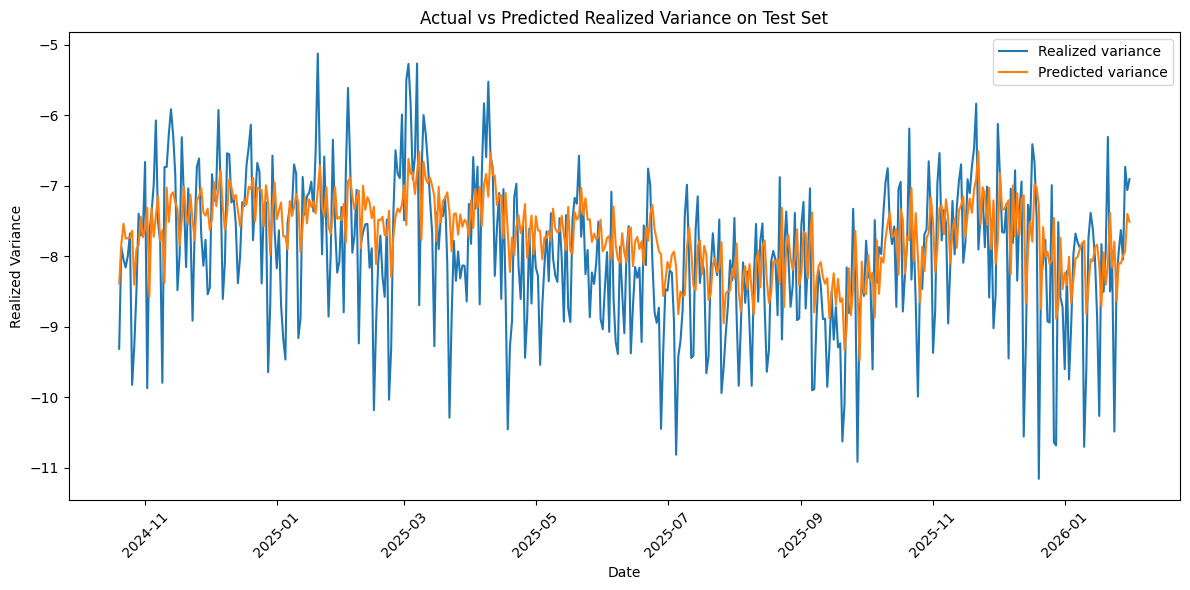

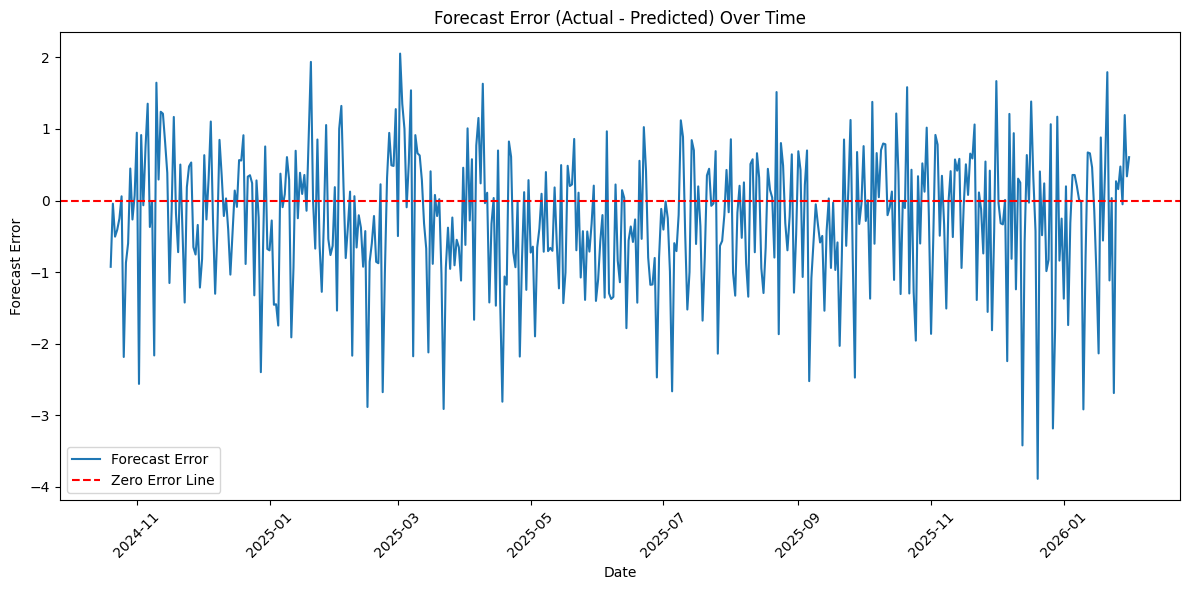

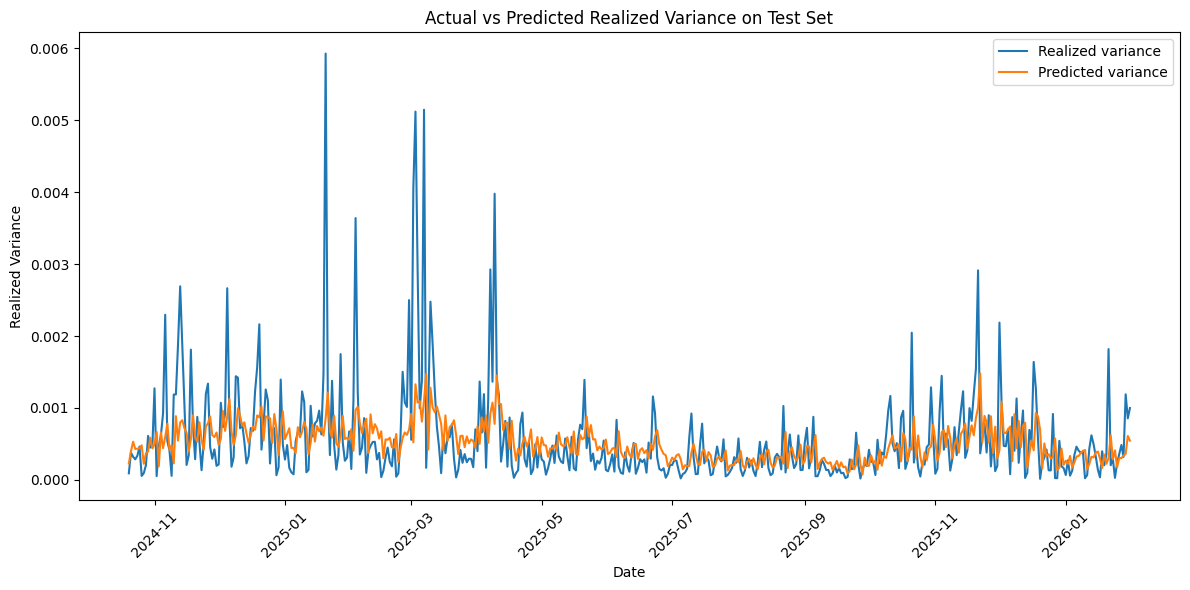

In [64]:
# plot actual vs predicted variance on test set
import matplotlib.pyplot as plt
test_svr['date'] = pd.to_datetime(test_svr['date'])
plt.figure(figsize=(12,6))
plt.plot(test_svr["date"], test_svr["actual_log_var"], label="Realized variance")
plt.plot(test_svr["date"], test_svr["log_var_svr"], label="Predicted variance")
plt.title("Actual vs Predicted Realized Variance on Test Set")
plt.xlabel("Date")
plt.ylabel("Realized Variance")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# plot errors over time
test_svr['date'] = pd.to_datetime(test_svr['date'])
test_svr['error'] = test_svr["actual_log_var"] - test_svr["log_var_svr"]
plt.figure(figsize=(12,6))
plt.plot(test_svr["date"], test_svr["error"], label="Forecast Error") 
plt.axhline(0, color='red', linestyle='--', label="Zero Error Line")
plt.title("Forecast Error (Actual - Predicted) Over Time")
plt.xlabel("Date")
plt.ylabel("Forecast Error")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


test_svr['date'] = pd.to_datetime(test_svr['date'])
plt.figure(figsize=(12,6))
plt.plot(test_svr["date"], np.exp(test_svr["actual_log_var"]), label="Realized variance")
plt.plot(test_svr["date"], np.exp(test_svr["log_var_svr"]), label="Predicted variance")
plt.title("Actual vs Predicted Realized Variance on Test Set")
plt.xlabel("Date")
plt.ylabel("Realized Variance")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# save test_svr results to csv
#test_svr.to_csv("neutral_results.csv", index=False)

In [65]:
df['date'] = pd.to_datetime(df['date'])
test_svr['date'] = pd.to_datetime(test_svr['date'])

result_df = test_svr.merge(
    df[["date", "regime_id"]],
    on="date",
    how="left"
)

result_df = result_df.rename(columns={"regime_id": "actual_regime"})

# classification report of predicted regime vs actual regime on test set
from sklearn.metrics import classification_report
# drop rows with NaN in pred_regime or actual_regime
result_df_clf = result_df.dropna(subset=["pred_regime", "actual_regime"])
print(classification_report(result_df_clf["actual_regime"], result_df_clf["pred_regime"]))


              precision    recall  f1-score   support

         0.0       0.46      1.00      0.63       214
         1.0       0.00      0.00      0.00       255

    accuracy                           0.46       469
   macro avg       0.23      0.50      0.31       469
weighted avg       0.21      0.46      0.29       469



/Users/jasonlow/Desktop/DSE4211-GRP13/tfenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jasonlow/Desktop/DSE4211-GRP13/tfenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jasonlow/Desktop/DSE4211-GRP13/tfenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

# Oracle Regime Model

In [27]:
def rolling_regime_forecast_oracle(
    df_full,
    start_idx,
    end_idx,
    date_col="date",
    target_col="regime_id"
):
    results = []

    for t in range(start_idx - 1, end_idx - 1):

        true_regime = int(df_full.iloc[t+1][target_col])

        results.append({
            "date": df_full.iloc[t][date_col],
            "pred_regime": true_regime,
            "pred_prob_0": 1.0 if true_regime == 0 else 0.0,
            "pred_prob_1": 1.0 if true_regime == 1 else 0.0
        })

    return pd.DataFrame(results)

In [28]:
stage2_window = 365
regime_start_idx = max(0, evalB_start_idx - stage2_window)

evalB_regime_oracle = rolling_regime_forecast_oracle(
    df_full=df,
    start_idx=regime_start_idx,
    end_idx=evalB_end_idx,
    date_col="date"
)

In [39]:
svr_results = []

for i, params in enumerate(svr_param_grid, 1):
    kernel = params["kernel"]
    C = params["C"]
    epsilon = params["epsilon"]

    print(f"\n[{i}/{len(svr_param_grid)}] Testing SVR: {params}")

    try:
        evalB_svr = rolling_lstm_svr_linear_eval(
            df_full=df,
            regime_forecast_df=evalB_regime_oracle,
            start_idx=evalB_start_idx,
            end_idx=evalB_end_idx,
            x_feature_cols=svr_features,
            realized_var_col="log_realized_variance",
            date_col="date",
            rolling_window=365,
            C=C,
            epsilon=epsilon,
            min_obs=200,
            use_prob_1_only=True
        )

        evalB_rmse = rmse(evalB_svr["actual_log_var"], evalB_svr["log_var_svr"])
        # convert to variance scale for qlike
        evalB_qlike = qlike(np.exp(evalB_svr["actual_log_var"]), np.exp(evalB_svr["log_var_svr"]))
        n_evalB_forecasts = evalB_svr["log_var_svr"].notna().sum()

        svr_results.append({
            **params,
            "evalB_rmse": evalB_rmse,
            "evalB_qlike": evalB_qlike,
            "n_evalB_forecasts": n_evalB_forecasts
        })

    except Exception as e:
        svr_results.append({
            **params,
            "evalB_rmse": np.nan,
            "evalB_qlike": np.nan,
            "n_evalB_forecasts": 0,
            "error": str(e)
        })

svr_results_df = pd.DataFrame(svr_results).sort_values("evalB_qlike")
#print(svr_results_df.head())


[1/9] Testing SVR: {'kernel': 'linear', 'C': 0.1, 'epsilon': 0.0001}

[2/9] Testing SVR: {'kernel': 'linear', 'C': 0.1, 'epsilon': 0.001}

[3/9] Testing SVR: {'kernel': 'linear', 'C': 0.1, 'epsilon': 0.01}

[4/9] Testing SVR: {'kernel': 'linear', 'C': 1.0, 'epsilon': 0.0001}

[5/9] Testing SVR: {'kernel': 'linear', 'C': 1.0, 'epsilon': 0.001}

[6/9] Testing SVR: {'kernel': 'linear', 'C': 1.0, 'epsilon': 0.01}

[7/9] Testing SVR: {'kernel': 'linear', 'C': 10.0, 'epsilon': 0.0001}

[8/9] Testing SVR: {'kernel': 'linear', 'C': 10.0, 'epsilon': 0.001}

[9/9] Testing SVR: {'kernel': 'linear', 'C': 10.0, 'epsilon': 0.01}


In [40]:
best_svr_params = svr_results_df.iloc[0].to_dict()
print(best_svr_params)

{'kernel': 'linear', 'C': 1.0, 'epsilon': 0.01, 'evalB_rmse': 0.7077812049410848, 'evalB_qlike': 0.2912011653259827, 'n_evalB_forecasts': 391}


In [41]:
stage2_window = 365
test_regime_start_idx = max(0, test_start_idx - stage2_window)

test_regime_oracle = rolling_regime_forecast_oracle(
    df_full=df,
    start_idx=test_regime_start_idx,
    end_idx=test_end_idx,
    date_col="date"
)

In [42]:
best_svr_C = best_svr_params["C"]
best_svr_param_e = best_svr_params["epsilon"]

test_svr = rolling_lstm_svr_linear_eval(
    df_full=df,
    regime_forecast_df=test_regime_oracle,
    start_idx=test_start_idx,
    end_idx=test_end_idx,
    x_feature_cols=svr_features,
    realized_var_col="log_realized_variance",
    date_col="date",
    rolling_window=365,
    C=float(best_svr_C),
    epsilon=float(best_svr_param_e),
    min_obs=200,
    use_prob_1_only=True
)

if len(test_svr) == 0:
    raise ValueError("No stage-2 SVR forecasts produced on test set.")

# RMSE on log-variance scale
test_rmse = rmse(
    test_svr["actual_log_var"],
    test_svr["log_var_svr"]
)

# RMSE on variance scale
test_rmse_var = rmse(
    np.exp(test_svr["actual_log_var"]),
    np.exp(test_svr["log_var_svr"])
)

# QLIKE on variance scale
test_qlike = qlike(
    np.exp(test_svr["actual_log_var"]),
    np.exp(test_svr["log_var_svr"])
)

print("Final Test RMSE :", test_rmse)
print("Final Test RMSE (var scale):", test_rmse_var)
print("Final Test QLIKE:", test_qlike)
print("Number of test forecasts:", test_svr["log_var_svr"].notna().sum())

Final Test RMSE : 0.7046524875535919
Final Test RMSE (var scale): 0.0005951171461590438
Final Test QLIKE: 0.259427370617517
Number of test forecasts: 469


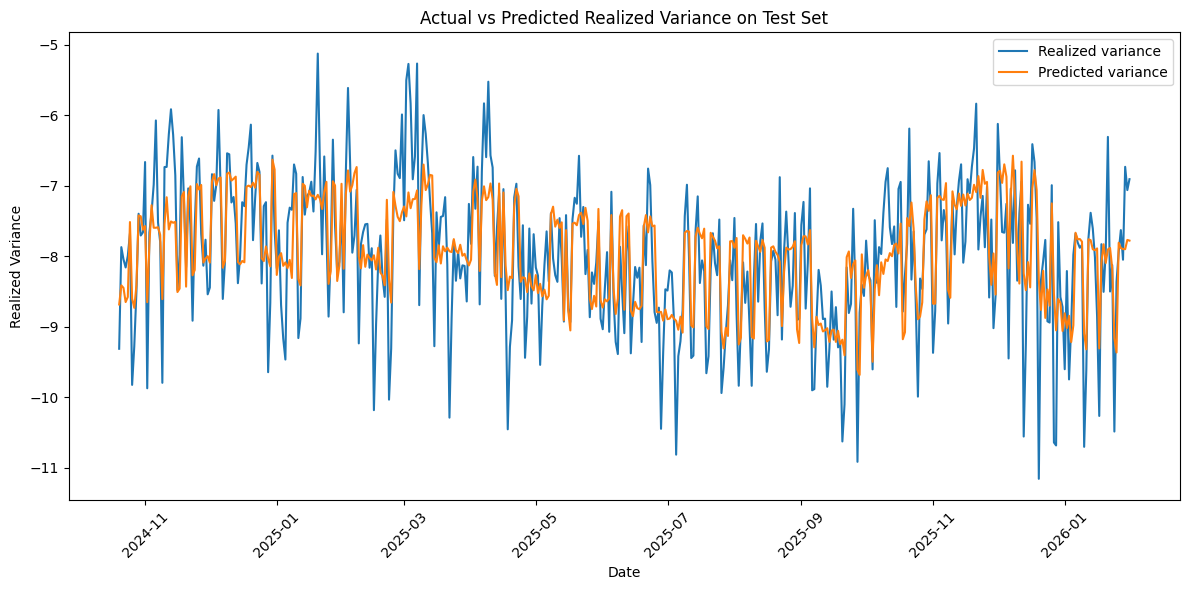

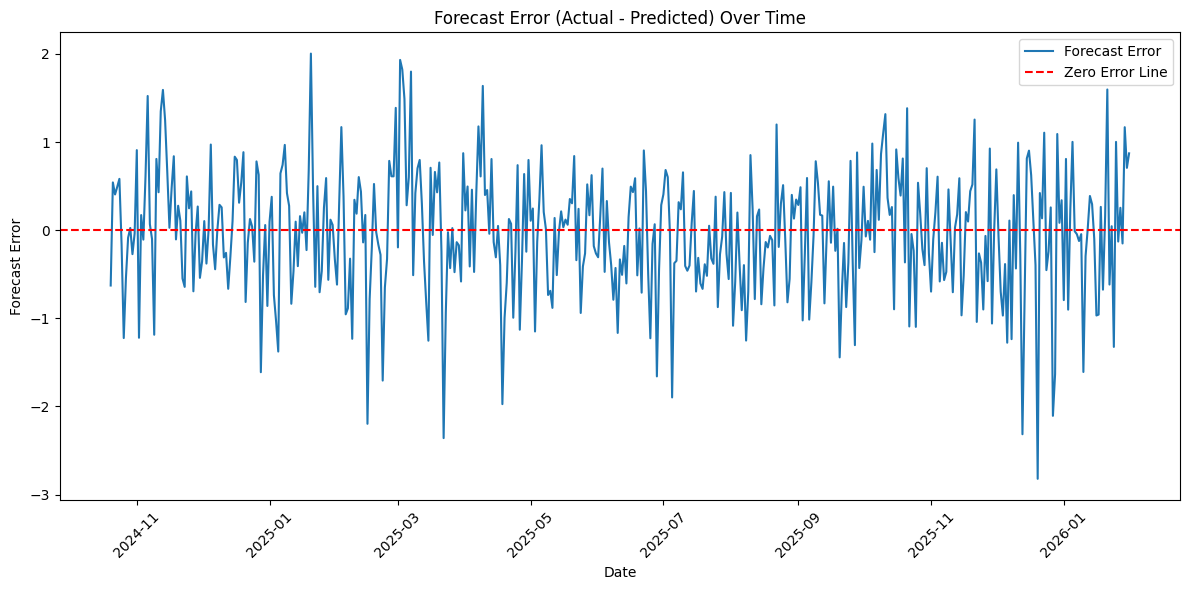

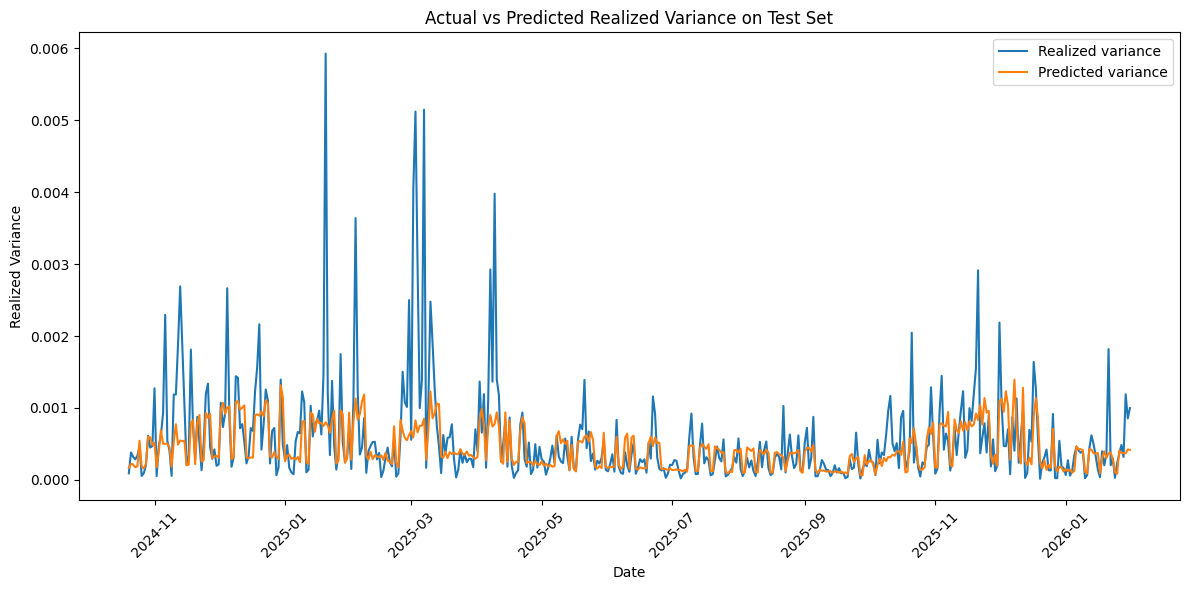

In [43]:
# plot actual vs predicted variance on test set
import matplotlib.pyplot as plt
test_svr['date'] = pd.to_datetime(test_svr['date'])
plt.figure(figsize=(12,6))
plt.plot(test_svr["date"], test_svr["actual_log_var"], label="Realized variance")
plt.plot(test_svr["date"], test_svr["log_var_svr"], label="Predicted variance")
plt.title("Actual vs Predicted Realized Variance on Test Set")
plt.xlabel("Date")
plt.ylabel("Realized Variance")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# plot errors over time
test_svr['date'] = pd.to_datetime(test_svr['date'])
test_svr['error'] = test_svr["actual_log_var"] - test_svr["log_var_svr"]
plt.figure(figsize=(12,6))
plt.plot(test_svr["date"], test_svr["error"], label="Forecast Error") 
plt.axhline(0, color='red', linestyle='--', label="Zero Error Line")
plt.title("Forecast Error (Actual - Predicted) Over Time")
plt.xlabel("Date")
plt.ylabel("Forecast Error")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


test_svr['date'] = pd.to_datetime(test_svr['date'])
plt.figure(figsize=(12,6))
plt.plot(test_svr["date"], np.exp(test_svr["actual_log_var"]), label="Realized variance")
plt.plot(test_svr["date"], np.exp(test_svr["log_var_svr"]), label="Predicted variance")
plt.title("Actual vs Predicted Realized Variance on Test Set")
plt.xlabel("Date")
plt.ylabel("Realized Variance")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# save test_svr results to csv
#test_svr.to_csv("oracle_results.csv", index=False)